In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

In [2]:
raw_train_data_path = "train_data.csv"
raw_test_data_path = "test_data.csv"

train_dataset = pd.read_csv(raw_train_data_path)
test_dataset = pd.read_csv(raw_test_data_path)

datasets = {"train": train_dataset, "test": test_dataset}


datasets["train"]

,SalePrice,YearBuilt,Size(sqf),Floor,HallwayType,HeatingType,AptManageType,N_Parkinglot(Ground),N_Parkinglot(Basement),TimeToBusStop,TimeToSubway,N_manager,N_elevators,SubwayStation,N_FacilitiesInApt,N_FacilitiesNearBy(Total),N_SchoolNearBy(Total)
0,141592,2006,814,3,terraced,individual_heating,management_in_trust,111.0,184.0,5min~10min,10min~15min,3.0,0.0,Kyungbuk_uni_hospital,5,6.0,9.0
1,51327,1985,587,8,corridor,individual_heating,self_management,80.0,76.0,0~5min,5min~10min,2.0,2.0,Daegu,3,12.0,4.0
2,48672,1985,587,6,corridor,individual_heating,self_management,80.0,76.0,0~5min,5min~10min,2.0,2.0,Daegu,3,12.0,4.0
3,380530,2006,2056,8,terraced,individual_heating,management_in_trust,249.0,536.0,0~5min,0-5min,5.0,11.0,Sin-nam,5,3.0,7.0
4,78318,1992,644,2,mixed,individual_heating,self_management,142.0,79.0,5min~10min,15min~20min,4.0,8.0,Myung-duk,3,9.0,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4119,570796,2007,1928,24,terraced,individual_heating,management_in_trust,0.0,1270.0,0~5min,0-5min,14.0,16.0,Kyungbuk_uni_hospital,10,9.0,10.0
4120,307079,2015,644,22,terraced,individual_heating,management_in_trust,102.0,400.0,0~5min,5min~10min,5.0,10.0,Daegu,7,7.0,11.0
4121,357522,2007,868,20,terraced,individual_heating,management_in_trust,0.0,1270.0,0~5min,0-5min,14.0,16.0,Kyungbuk_uni_hospital,10,9.0,10.0
4122,312389,1978,1327,1,corridor,individual_heating,self_management,87.0,0.0,0~5min,0-5min,1.0,4.0,Kyungbuk_uni_hospital,3,7.0,11.0


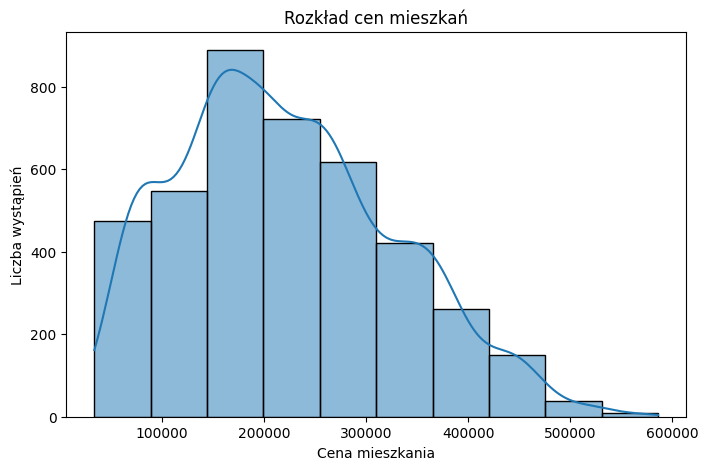

In [3]:
plt.figure(figsize=(8, 5))
sns.histplot(train_dataset["SalePrice"], bins=10, kde=True)
plt.xlabel("Cena mieszkania")
plt.ylabel("Liczba wystąpień")
plt.title("Rozkład cen mieszkań")
plt.show()

In [4]:
def classify_price(price: int):
    if price <= 100000:
        return "cheap"
    elif price <= 350000:
        return "average"
    else:
        return "expensive"


train_dataset["PriceCategory"] = train_dataset["SalePrice"].apply(classify_price)
train_dataset["PriceCategoryNum"] = train_dataset["PriceCategory"].map(
    {"cheap": 0.0, "average": 1.0, "expensive": 2.0}
)

train_dataset

,SalePrice,YearBuilt,Size(sqf),Floor,HallwayType,HeatingType,AptManageType,N_Parkinglot(Ground),N_Parkinglot(Basement),TimeToBusStop,TimeToSubway,N_manager,N_elevators,SubwayStation,N_FacilitiesInApt,N_FacilitiesNearBy(Total),N_SchoolNearBy(Total),PriceCategory,PriceCategoryNum
0,141592,2006,814,3,terraced,individual_heating,management_in_trust,111.0,184.0,5min~10min,10min~15min,3.0,0.0,Kyungbuk_uni_hospital,5,6.0,9.0,average,1.0
1,51327,1985,587,8,corridor,individual_heating,self_management,80.0,76.0,0~5min,5min~10min,2.0,2.0,Daegu,3,12.0,4.0,cheap,0.0
2,48672,1985,587,6,corridor,individual_heating,self_management,80.0,76.0,0~5min,5min~10min,2.0,2.0,Daegu,3,12.0,4.0,cheap,0.0
3,380530,2006,2056,8,terraced,individual_heating,management_in_trust,249.0,536.0,0~5min,0-5min,5.0,11.0,Sin-nam,5,3.0,7.0,expensive,2.0
4,78318,1992,644,2,mixed,individual_heating,self_management,142.0,79.0,5min~10min,15min~20min,4.0,8.0,Myung-duk,3,9.0,14.0,cheap,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4119,570796,2007,1928,24,terraced,individual_heating,management_in_trust,0.0,1270.0,0~5min,0-5min,14.0,16.0,Kyungbuk_uni_hospital,10,9.0,10.0,expensive,2.0
4120,307079,2015,644,22,terraced,individual_heating,management_in_trust,102.0,400.0,0~5min,5min~10min,5.0,10.0,Daegu,7,7.0,11.0,average,1.0
4121,357522,2007,868,20,terraced,individual_heating,management_in_trust,0.0,1270.0,0~5min,0-5min,14.0,16.0,Kyungbuk_uni_hospital,10,9.0,10.0,expensive,2.0
4122,312389,1978,1327,1,corridor,individual_heating,self_management,87.0,0.0,0~5min,0-5min,1.0,4.0,Kyungbuk_uni_hospital,3,7.0,11.0,average,1.0


/var/folders/rh/8hh2vd4j4xzcvyl1kj3kzf600000gn/T/ipykernel_95781/2715099235.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


Text(0.5, 1.0, 'Liczba wystąpień każdej klasy cenowej')

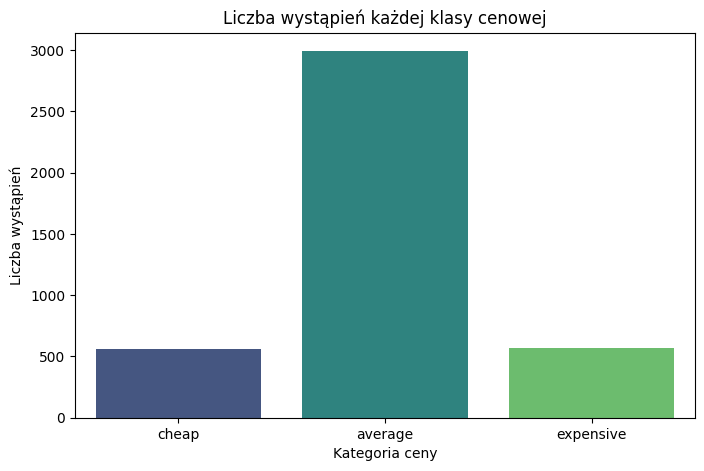

In [5]:
order = ["cheap", "average", "expensive"]
class_counts = train_dataset["PriceCategory"].value_counts()[order]

plt.figure(figsize=(8, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


plt.xlabel("Kategoria ceny")
plt.ylabel("Liczba wystąpień")
plt.title("Liczba wystąpień każdej klasy cenowej")

In [6]:
for key, dataset in datasets.items():
    datasets[key] = dataset.map(lambda x: float(x) if isinstance(x, int) else x)

In [7]:
unique_categorical_values = train_dataset.select_dtypes(include=["object"]).nunique()
unique_categorical_values

HallwayType      3
HeatingType      2
AptManageType    2
TimeToBusStop    3
TimeToSubway     5
SubwayStation    8
PriceCategory    3
dtype: int64

In [8]:
datasets["train"]

,SalePrice,YearBuilt,Size(sqf),Floor,HallwayType,HeatingType,AptManageType,N_Parkinglot(Ground),N_Parkinglot(Basement),TimeToBusStop,TimeToSubway,N_manager,N_elevators,SubwayStation,N_FacilitiesInApt,N_FacilitiesNearBy(Total),N_SchoolNearBy(Total),PriceCategory,PriceCategoryNum
0,141592.0,2006.0,814.0,3.0,terraced,individual_heating,management_in_trust,111.0,184.0,5min~10min,10min~15min,3.0,0.0,Kyungbuk_uni_hospital,5.0,6.0,9.0,average,1.0
1,51327.0,1985.0,587.0,8.0,corridor,individual_heating,self_management,80.0,76.0,0~5min,5min~10min,2.0,2.0,Daegu,3.0,12.0,4.0,cheap,0.0
2,48672.0,1985.0,587.0,6.0,corridor,individual_heating,self_management,80.0,76.0,0~5min,5min~10min,2.0,2.0,Daegu,3.0,12.0,4.0,cheap,0.0
3,380530.0,2006.0,2056.0,8.0,terraced,individual_heating,management_in_trust,249.0,536.0,0~5min,0-5min,5.0,11.0,Sin-nam,5.0,3.0,7.0,expensive,2.0
4,78318.0,1992.0,644.0,2.0,mixed,individual_heating,self_management,142.0,79.0,5min~10min,15min~20min,4.0,8.0,Myung-duk,3.0,9.0,14.0,cheap,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4119,570796.0,2007.0,1928.0,24.0,terraced,individual_heating,management_in_trust,0.0,1270.0,0~5min,0-5min,14.0,16.0,Kyungbuk_uni_hospital,10.0,9.0,10.0,expensive,2.0
4120,307079.0,2015.0,644.0,22.0,terraced,individual_heating,management_in_trust,102.0,400.0,0~5min,5min~10min,5.0,10.0,Daegu,7.0,7.0,11.0,average,1.0
4121,357522.0,2007.0,868.0,20.0,terraced,individual_heating,management_in_trust,0.0,1270.0,0~5min,0-5min,14.0,16.0,Kyungbuk_uni_hospital,10.0,9.0,10.0,expensive,2.0
4122,312389.0,1978.0,1327.0,1.0,corridor,individual_heating,self_management,87.0,0.0,0~5min,0-5min,1.0,4.0,Kyungbuk_uni_hospital,3.0,7.0,11.0,average,1.0


In [9]:
def convert_time_to_avg(time_range: str):
    try:
        parts = time_range.replace("min", "").replace("-", "~").split("~")
        lower, upper = map(int, parts)
        return (lower + upper) / 2
    except Exception:
        return np.nan

In [10]:
for dataset in datasets.values():
    dataset["TimeToBusStop"] = dataset["TimeToBusStop"].apply(convert_time_to_avg)
    dataset["TimeToSubway"] = dataset["TimeToSubway"].apply(convert_time_to_avg)

datasets["train"]

,SalePrice,YearBuilt,Size(sqf),Floor,HallwayType,HeatingType,AptManageType,N_Parkinglot(Ground),N_Parkinglot(Basement),TimeToBusStop,TimeToSubway,N_manager,N_elevators,SubwayStation,N_FacilitiesInApt,N_FacilitiesNearBy(Total),N_SchoolNearBy(Total),PriceCategory,PriceCategoryNum
0,141592.0,2006.0,814.0,3.0,terraced,individual_heating,management_in_trust,111.0,184.0,7.5,12.5,3.0,0.0,Kyungbuk_uni_hospital,5.0,6.0,9.0,average,1.0
1,51327.0,1985.0,587.0,8.0,corridor,individual_heating,self_management,80.0,76.0,2.5,7.5,2.0,2.0,Daegu,3.0,12.0,4.0,cheap,0.0
2,48672.0,1985.0,587.0,6.0,corridor,individual_heating,self_management,80.0,76.0,2.5,7.5,2.0,2.0,Daegu,3.0,12.0,4.0,cheap,0.0
3,380530.0,2006.0,2056.0,8.0,terraced,individual_heating,management_in_trust,249.0,536.0,2.5,2.5,5.0,11.0,Sin-nam,5.0,3.0,7.0,expensive,2.0
4,78318.0,1992.0,644.0,2.0,mixed,individual_heating,self_management,142.0,79.0,7.5,17.5,4.0,8.0,Myung-duk,3.0,9.0,14.0,cheap,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4119,570796.0,2007.0,1928.0,24.0,terraced,individual_heating,management_in_trust,0.0,1270.0,2.5,2.5,14.0,16.0,Kyungbuk_uni_hospital,10.0,9.0,10.0,expensive,2.0
4120,307079.0,2015.0,644.0,22.0,terraced,individual_heating,management_in_trust,102.0,400.0,2.5,7.5,5.0,10.0,Daegu,7.0,7.0,11.0,average,1.0
4121,357522.0,2007.0,868.0,20.0,terraced,individual_heating,management_in_trust,0.0,1270.0,2.5,2.5,14.0,16.0,Kyungbuk_uni_hospital,10.0,9.0,10.0,expensive,2.0
4122,312389.0,1978.0,1327.0,1.0,corridor,individual_heating,self_management,87.0,0.0,2.5,2.5,1.0,4.0,Kyungbuk_uni_hospital,3.0,7.0,11.0,average,1.0


In [11]:
max_bus_time = max(dataset["TimeToBusStop"].max() for dataset in datasets.values())
max_subway_time = max(dataset["TimeToSubway"].max() for dataset in datasets.values())

for dataset in datasets.values():
    dataset["TimeToBusStop"] = dataset["TimeToBusStop"].fillna(2 * max_bus_time)
    dataset["TimeToSubway"] = dataset["TimeToSubway"].fillna(2 * max_subway_time)

datasets["train"]

,SalePrice,YearBuilt,Size(sqf),Floor,HallwayType,HeatingType,AptManageType,N_Parkinglot(Ground),N_Parkinglot(Basement),TimeToBusStop,TimeToSubway,N_manager,N_elevators,SubwayStation,N_FacilitiesInApt,N_FacilitiesNearBy(Total),N_SchoolNearBy(Total),PriceCategory,PriceCategoryNum
0,141592.0,2006.0,814.0,3.0,terraced,individual_heating,management_in_trust,111.0,184.0,7.5,12.5,3.0,0.0,Kyungbuk_uni_hospital,5.0,6.0,9.0,average,1.0
1,51327.0,1985.0,587.0,8.0,corridor,individual_heating,self_management,80.0,76.0,2.5,7.5,2.0,2.0,Daegu,3.0,12.0,4.0,cheap,0.0
2,48672.0,1985.0,587.0,6.0,corridor,individual_heating,self_management,80.0,76.0,2.5,7.5,2.0,2.0,Daegu,3.0,12.0,4.0,cheap,0.0
3,380530.0,2006.0,2056.0,8.0,terraced,individual_heating,management_in_trust,249.0,536.0,2.5,2.5,5.0,11.0,Sin-nam,5.0,3.0,7.0,expensive,2.0
4,78318.0,1992.0,644.0,2.0,mixed,individual_heating,self_management,142.0,79.0,7.5,17.5,4.0,8.0,Myung-duk,3.0,9.0,14.0,cheap,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4119,570796.0,2007.0,1928.0,24.0,terraced,individual_heating,management_in_trust,0.0,1270.0,2.5,2.5,14.0,16.0,Kyungbuk_uni_hospital,10.0,9.0,10.0,expensive,2.0
4120,307079.0,2015.0,644.0,22.0,terraced,individual_heating,management_in_trust,102.0,400.0,2.5,7.5,5.0,10.0,Daegu,7.0,7.0,11.0,average,1.0
4121,357522.0,2007.0,868.0,20.0,terraced,individual_heating,management_in_trust,0.0,1270.0,2.5,2.5,14.0,16.0,Kyungbuk_uni_hospital,10.0,9.0,10.0,expensive,2.0
4122,312389.0,1978.0,1327.0,1.0,corridor,individual_heating,self_management,87.0,0.0,2.5,2.5,1.0,4.0,Kyungbuk_uni_hospital,3.0,7.0,11.0,average,1.0


In [12]:
unique_categorical_values = train_dataset.select_dtypes(include=["object"]).nunique()
unique_categorical_values

HallwayType      3
HeatingType      2
AptManageType    2
TimeToBusStop    3
TimeToSubway     5
SubwayStation    8
PriceCategory    3
dtype: int64

In [13]:
for dataset in datasets.values():
    dataset["HeatingType"] = dataset["HeatingType"].map(
        {"central_heating": 1.0, "individual_heating": 0.0},
    )

    dataset["AptManageType"] = dataset["AptManageType"].map(
        {"self_management": 1.0, "management_in_trust": 0.0}
    )


datasets["train"]

,SalePrice,YearBuilt,Size(sqf),Floor,HallwayType,HeatingType,AptManageType,N_Parkinglot(Ground),N_Parkinglot(Basement),TimeToBusStop,TimeToSubway,N_manager,N_elevators,SubwayStation,N_FacilitiesInApt,N_FacilitiesNearBy(Total),N_SchoolNearBy(Total),PriceCategory,PriceCategoryNum
0,141592.0,2006.0,814.0,3.0,terraced,0.0,0.0,111.0,184.0,7.5,12.5,3.0,0.0,Kyungbuk_uni_hospital,5.0,6.0,9.0,average,1.0
1,51327.0,1985.0,587.0,8.0,corridor,0.0,1.0,80.0,76.0,2.5,7.5,2.0,2.0,Daegu,3.0,12.0,4.0,cheap,0.0
2,48672.0,1985.0,587.0,6.0,corridor,0.0,1.0,80.0,76.0,2.5,7.5,2.0,2.0,Daegu,3.0,12.0,4.0,cheap,0.0
3,380530.0,2006.0,2056.0,8.0,terraced,0.0,0.0,249.0,536.0,2.5,2.5,5.0,11.0,Sin-nam,5.0,3.0,7.0,expensive,2.0
4,78318.0,1992.0,644.0,2.0,mixed,0.0,1.0,142.0,79.0,7.5,17.5,4.0,8.0,Myung-duk,3.0,9.0,14.0,cheap,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4119,570796.0,2007.0,1928.0,24.0,terraced,0.0,0.0,0.0,1270.0,2.5,2.5,14.0,16.0,Kyungbuk_uni_hospital,10.0,9.0,10.0,expensive,2.0
4120,307079.0,2015.0,644.0,22.0,terraced,0.0,0.0,102.0,400.0,2.5,7.5,5.0,10.0,Daegu,7.0,7.0,11.0,average,1.0
4121,357522.0,2007.0,868.0,20.0,terraced,0.0,0.0,0.0,1270.0,2.5,2.5,14.0,16.0,Kyungbuk_uni_hospital,10.0,9.0,10.0,expensive,2.0
4122,312389.0,1978.0,1327.0,1.0,corridor,0.0,1.0,87.0,0.0,2.5,2.5,1.0,4.0,Kyungbuk_uni_hospital,3.0,7.0,11.0,average,1.0


In [14]:
unique_categorical_values = train_dataset.select_dtypes(include=["object"]).nunique()
unique_categorical_values

HallwayType      3
HeatingType      2
AptManageType    2
TimeToBusStop    3
TimeToSubway     5
SubwayStation    8
PriceCategory    3
dtype: int64

In [15]:
for key, dataset in datasets.items():
    datasets[key] = pd.get_dummies(
        dataset, columns=["HallwayType", "SubwayStation"], dtype=float
    )

datasets["train"]

,SalePrice,YearBuilt,Size(sqf),Floor,HeatingType,AptManageType,N_Parkinglot(Ground),N_Parkinglot(Basement),TimeToBusStop,TimeToSubway,...,HallwayType_mixed,HallwayType_terraced,SubwayStation_Bangoge,SubwayStation_Banwoldang,SubwayStation_Chil-sung-market,SubwayStation_Daegu,SubwayStation_Kyungbuk_uni_hospital,SubwayStation_Myung-duk,SubwayStation_Sin-nam,SubwayStation_no_subway_nearby
0,141592.0,2006.0,814.0,3.0,0.0,0.0,111.0,184.0,7.5,12.5,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,51327.0,1985.0,587.0,8.0,0.0,1.0,80.0,76.0,2.5,7.5,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,48672.0,1985.0,587.0,6.0,0.0,1.0,80.0,76.0,2.5,7.5,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,380530.0,2006.0,2056.0,8.0,0.0,0.0,249.0,536.0,2.5,2.5,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,78318.0,1992.0,644.0,2.0,0.0,1.0,142.0,79.0,7.5,17.5,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4119,570796.0,2007.0,1928.0,24.0,0.0,0.0,0.0,1270.0,2.5,2.5,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4120,307079.0,2015.0,644.0,22.0,0.0,0.0,102.0,400.0,2.5,7.5,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4121,357522.0,2007.0,868.0,20.0,0.0,0.0,0.0,1270.0,2.5,2.5,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4122,312389.0,1978.0,1327.0,1.0,0.0,1.0,87.0,0.0,2.5,2.5,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


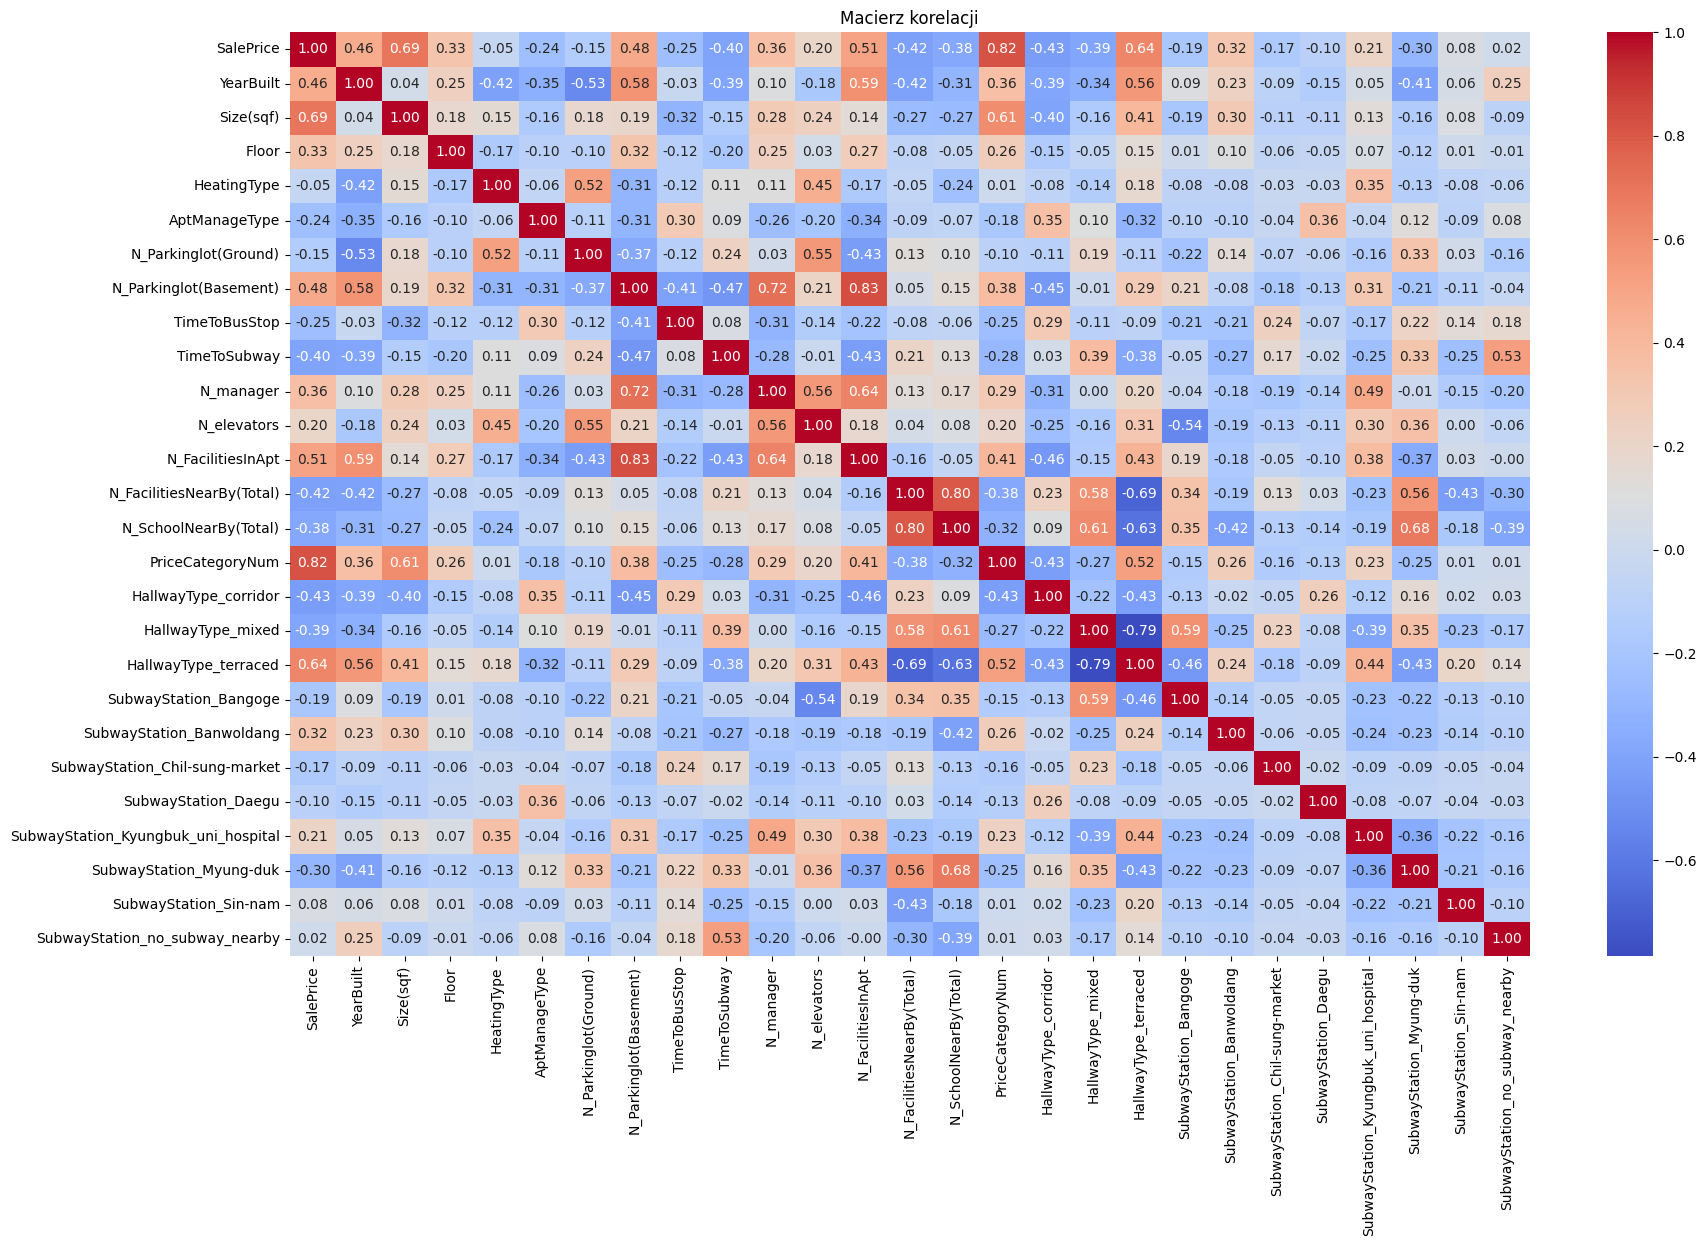

In [16]:
plt.figure(figsize=(20, 12))
sns.heatmap(
    datasets["train"].corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f"
)
plt.title("Macierz korelacji")
plt.show()

In [17]:
train_dataset = datasets["train"]
cols_to_reorder = ["SalePrice", "PriceCategoryNum", "PriceCategory"]

datasets["train"] = train_dataset[
    [col for col in train_dataset.columns if col not in cols_to_reorder]
    + cols_to_reorder
]

datasets["train"]

,YearBuilt,Size(sqf),Floor,HeatingType,AptManageType,N_Parkinglot(Ground),N_Parkinglot(Basement),TimeToBusStop,TimeToSubway,N_manager,...,SubwayStation_Banwoldang,SubwayStation_Chil-sung-market,SubwayStation_Daegu,SubwayStation_Kyungbuk_uni_hospital,SubwayStation_Myung-duk,SubwayStation_Sin-nam,SubwayStation_no_subway_nearby,SalePrice,PriceCategoryNum,PriceCategory
0,2006.0,814.0,3.0,0.0,0.0,111.0,184.0,7.5,12.5,3.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,141592.0,1.0,average
1,1985.0,587.0,8.0,0.0,1.0,80.0,76.0,2.5,7.5,2.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,51327.0,0.0,cheap
2,1985.0,587.0,6.0,0.0,1.0,80.0,76.0,2.5,7.5,2.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,48672.0,0.0,cheap
3,2006.0,2056.0,8.0,0.0,0.0,249.0,536.0,2.5,2.5,5.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,380530.0,2.0,expensive
4,1992.0,644.0,2.0,0.0,1.0,142.0,79.0,7.5,17.5,4.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,78318.0,0.0,cheap
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4119,2007.0,1928.0,24.0,0.0,0.0,0.0,1270.0,2.5,2.5,14.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,570796.0,2.0,expensive
4120,2015.0,644.0,22.0,0.0,0.0,102.0,400.0,2.5,7.5,5.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,307079.0,1.0,average
4121,2007.0,868.0,20.0,0.0,0.0,0.0,1270.0,2.5,2.5,14.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,357522.0,2.0,expensive
4122,1978.0,1327.0,1.0,0.0,1.0,87.0,0.0,2.5,2.5,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,312389.0,1.0,average


In [18]:
for key, dataset in datasets.items():
    dataset.to_csv(f"{key}_dataset.csv", index=False)

In [19]:
datasets["train"].describe()

,YearBuilt,Size(sqf),Floor,HeatingType,AptManageType,N_Parkinglot(Ground),N_Parkinglot(Basement),TimeToBusStop,TimeToSubway,N_manager,...,SubwayStation_Bangoge,SubwayStation_Banwoldang,SubwayStation_Chil-sung-market,SubwayStation_Daegu,SubwayStation_Kyungbuk_uni_hospital,SubwayStation_Myung-duk,SubwayStation_Sin-nam,SubwayStation_no_subway_nearby,SalePrice,PriceCategoryNum
count,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,...,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000
mean,2002.977934,959.958778,11.994665,0.045102,0.061833,192.789040,572.857662,3.729389,8.508729,6.313773,...,0.124151,0.128758,0.020611,0.015034,0.272793,0.258244,0.113482,0.066925,222177.477207,1.001940
std,8.765838,384.548456,7.581330,0.207553,0.240882,215.455916,408.179957,2.257765,7.789660,3.224556,...,0.329794,0.334973,0.142096,0.121703,0.445450,0.437722,0.317220,0.249923,106325.535526,0.523979
min,1978.000000,135.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.500000,2.500000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,34070.000000,0.000000
25%,1993.000000,644.000000,6.000000,0.000000,0.000000,11.000000,184.000000,2.500000,2.500000,5.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,144752.000000,1.000000
50%,2006.000000,910.000000,11.000000,0.000000,0.000000,100.000000,536.000000,2.500000,7.500000,6.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,209588.000000,1.000000
75%,2007.000000,1160.000000,17.000000,0.000000,0.000000,249.000000,798.000000,2.500000,12.500000,8.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,291570.000000,1.000000
max,2015.000000,2337.000000,43.000000,1.000000,1.000000,713.000000,1321.000000,12.500000,35.000000,14.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,585840.000000,2.000000


In [20]:
from sklearn.preprocessing import StandardScaler

features_scaler = StandardScaler()
sale_price_scaler = StandardScaler()


datasets["train"].iloc[:, :-3] = features_scaler.fit_transform(
    datasets["train"].iloc[:, :-3]
)
datasets["test"] = pd.DataFrame(
    features_scaler.transform(datasets["test"]), columns=datasets["test"].columns
)

datasets["train"]["SalePrice"] = sale_price_scaler.fit_transform(
    datasets["train"][["SalePrice"]]
)

In [24]:
datasets["test"].describe()

,YearBuilt,Size(sqf),Floor,HeatingType,AptManageType,N_Parkinglot(Ground),N_Parkinglot(Basement),TimeToBusStop,TimeToSubway,N_manager,...,HallwayType_mixed,HallwayType_terraced,SubwayStation_Bangoge,SubwayStation_Banwoldang,SubwayStation_Chil-sung-market,SubwayStation_Daegu,SubwayStation_Kyungbuk_uni_hospital,SubwayStation_Myung-duk,SubwayStation_Sin-nam,SubwayStation_no_subway_nearby
count,1767.000000,1767.000000,1767.000000,1767.000000,1767.000000,1767.000000,1767.000000,1767.000000,1767.000000,1767.000000,...,1767.000000,1767.000000,1767.000000,1767.000000,1767.000000,1767.000000,1767.000000,1767.000000,1767.000000,1767.000000
mean,-0.004004,-0.038061,0.013918,0.093550,-0.035855,0.047889,-0.017122,-0.014372,0.026708,-0.003587,...,-0.019454,0.016489,0.009653,-0.017769,-0.025571,-0.016580,0.046980,-0.018514,-0.031265,0.022065
std,1.017771,0.981696,0.985929,1.184130,0.932068,1.047468,1.003901,0.994063,1.001347,0.947201,...,0.991021,0.996684,1.011183,0.980223,0.909535,0.931701,1.022896,0.989828,0.960909,1.037594
min,-2.849809,-2.145526,-1.450405,-0.217329,-0.256727,-0.894904,-1.403614,-0.544582,-0.771466,-1.648108,...,-0.638364,-1.231328,-0.376497,-0.384431,-0.145068,-0.123545,-0.612475,-0.590045,-0.357783,-0.267816
25%,-1.138413,-0.821735,-0.790810,-0.217329,-0.256727,-0.843844,-0.952778,-0.544582,-0.771466,-0.407477,...,-0.638364,-1.231328,-0.376497,-0.384431,-0.145068,-0.123545,-0.612475,-0.590045,-0.357783,-0.267816
50%,0.344797,-0.129931,-0.131215,-0.217329,-0.256727,-0.430716,-0.090309,-0.544582,-0.129512,-0.097319,...,-0.638364,0.812131,-0.376497,-0.384431,-0.145068,-0.123545,-0.612475,-0.590045,-0.357783,-0.267816
75%,0.572983,0.444839,0.660299,-0.217329,-0.256727,0.260925,0.551643,-0.544582,0.512443,0.522996,...,1.566504,0.812131,-0.376497,-0.384431,-0.145068,-0.123545,1.632721,0.552371,-0.357783,-0.267816
max,1.371634,3.581365,3.958273,4.601309,3.895196,2.414759,1.833096,3.885115,3.401238,2.383943,...,1.566504,0.812131,2.656066,2.601246,6.893305,8.094203,1.632721,1.694786,2.794989,3.733903


In [22]:
joblib.dump(features_scaler, "features_scaler.pkl")
joblib.dump(sale_price_scaler, "sale_price_scaler.pkl")

['sale_price_scaler.pkl']